# Feature Builder

This notebook is strictly for feature creation and feature plots. It does not build targets, correlations, IC tables, or distribution diagnostics.

Default bucket size is `BAR_MINUTES = 5`. Override with `MODL_BAR_MINUTES=1` or `MODL_BAR_MINUTES=15` before launching Jupyter.

In [1]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

if "notebooks" not in sys.path:
    sys.path.append("notebooks")

from advanced_features import (
    build_feature_set,
    discover_datasets,
    plot_realized_vol,
    plot_term_structure,
)

ROOT = Path(os.environ.get("MODL_WS_NORMALIZED_DIR", "/mnt/burner-archive/ws_normalized")).expanduser()
DATE = os.environ.get("MODL_VIEW_DATE", "2026-06-30")
DATE_TAG = datetime.strptime(DATE, "%Y-%m-%d").strftime("%y-%m-%d")
FEATURE_ROOT = Path(os.environ.get("MODL_WS_FEATURE_DIR", "/mnt/burner-archive/ws_features")).expanduser()
BAR_MINUTES = int(os.environ.get("MODL_BAR_MINUTES", "5"))
HORIZONS = (5, 15, 30)
SAVE_OUTPUTS = False

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_colwidth", 180)
pl.Config.set_tbl_cols(240)
pl.Config.set_tbl_rows(24)

DATASETS = discover_datasets(ROOT, DATE_TAG)
if not DATASETS:
    raise FileNotFoundError(f"No normalized Parquet files found under {ROOT} for {DATE}")

ROOT, DATE, DATE_TAG, BAR_MINUTES, len(DATASETS)


(PosixPath('/mnt/burner-archive/ws_normalized'),
 '2026-06-30',
 '26-06-30',
 5,
 14)

## Build 5-Minute Feature Set

In [2]:
feature_set = build_feature_set(DATASETS, horizons=HORIZONS, bar_minutes=BAR_MINUTES)
feature_matrix = feature_set.feature_matrix
base_feature_matrix = feature_set.base_feature_matrix
trade_features = feature_set.trade_features
book_features = feature_set.book_features
deribit_option_features = feature_set.deribit_option_features
term_structure_features = feature_set.term_structure
option_smile_features = feature_set.option_smile
futures_basis_features = feature_set.futures_basis
funding_features = feature_set.funding_features
rv_features = feature_set.rv_features
reference_price = feature_set.reference_price

df = feature_matrix
df_stats = df.describe().T

component_shapes = pd.DataFrame(
    [
        ("feature_matrix", *feature_matrix.shape),
        ("base_feature_matrix", *base_feature_matrix.shape),
        ("trade_features", trade_features.height, trade_features.width),
        ("book_features", book_features.height, book_features.width),
        ("deribit_option_features", *deribit_option_features.shape),
        ("term_structure_features", *term_structure_features.shape),
        ("option_smile_features", *option_smile_features.shape),
        ("futures_basis_features", *futures_basis_features.shape),
        ("funding_features", *funding_features.shape),
        ("rv_features", *rv_features.shape),
    ],
    columns=["component", "rows", "columns"],
)
component_shapes

,component,rows,columns
0,feature_matrix,21,436
1,base_feature_matrix,21,28
2,trade_features,61,10
3,book_features,58,9
4,deribit_option_features,19,5
5,term_structure_features,19,15
6,option_smile_features,19,12
7,futures_basis_features,19,17
8,funding_features,19,2
9,rv_features,21,20


In [3]:
df_stats.head(80)

,count,mean,std,min,25%,50%,75%,max
trade_flow_imbalance_bitfinex,21.0,0.055442,0.631522,-0.997826,-0.464341,0.074621,0.528946,0.995664
trade_flow_imbalance_hibachi,19.0,-0.064657,0.648037,-1.000000,-0.588733,-0.068179,0.397294,0.938698
trade_flow_imbalance_hyperliquid,21.0,-0.226090,0.707308,-1.000000,-0.816667,-0.423936,0.113622,0.975536
trade_trade_count_bitfinex,21.0,107.571429,36.775768,48.000000,90.000000,97.000000,121.000000,201.000000
trade_trade_count_hibachi,19.0,27.368421,13.545030,3.000000,23.000000,27.000000,29.000000,64.000000
...,...,...,...,...,...,...,...,...
smile_atm_call_iv_count,19.0,780.894737,250.005532,97.000000,686.500000,742.000000,955.000000,1149.000000
smile_atm_put_iv_count,19.0,814.736842,269.815336,92.000000,696.500000,811.000000,992.000000,1236.000000
smile_otm_call_iv_count,19.0,432.736842,111.483851,97.000000,404.500000,417.000000,508.500000,605.000000
smile_otm_put_iv_count,19.0,327.684211,83.183901,69.000000,303.500000,336.000000,375.500000,433.000000


## Trade Flow Features

In [4]:
trade_features.head(30)

minute,trade_count,volume,notional,signed_volume,buy_count,sell_count,venue,vwap,flow_imbalance
datetime[μs],u32,f64,f64,f64,i64,i64,str,f64,f64
2026-06-30 03:20:00,48,0.919966,55085.416055,-0.917966,1,47,"""bitfinex""",59877.663802,-0.997826
2026-06-30 03:25:00,90,1.105517,66169.777804,0.082495,50,40,"""bitfinex""",59854.163943,0.074621
2026-06-30 03:30:00,97,1.291627,77213.034494,-0.456852,22,75,"""bitfinex""",59779.649532,-0.353703
2026-06-30 03:35:00,90,0.392539,23464.4358,-0.208076,36,54,"""bitfinex""",59776.111235,-0.530077
2026-06-30 03:40:00,76,3.652246,218202.636817,2.401791,34,42,"""bitfinex""",59744.782305,0.65762
2026-06-30 03:45:00,149,2.707827,161542.853991,-1.253665,56,93,"""bitfinex""",59657.738218,-0.462978
2026-06-30 03:50:00,98,1.165161,69504.225478,-1.097108,28,70,"""bitfinex""",59652.01412,-0.941593
2026-06-30 03:55:00,94,0.552125,32910.360608,0.178604,48,46,"""bitfinex""",59606.716276,0.323484
2026-06-30 04:00:00,124,0.432508,25769.041978,-0.145748,46,78,"""bitfinex""",59580.493749,-0.336984


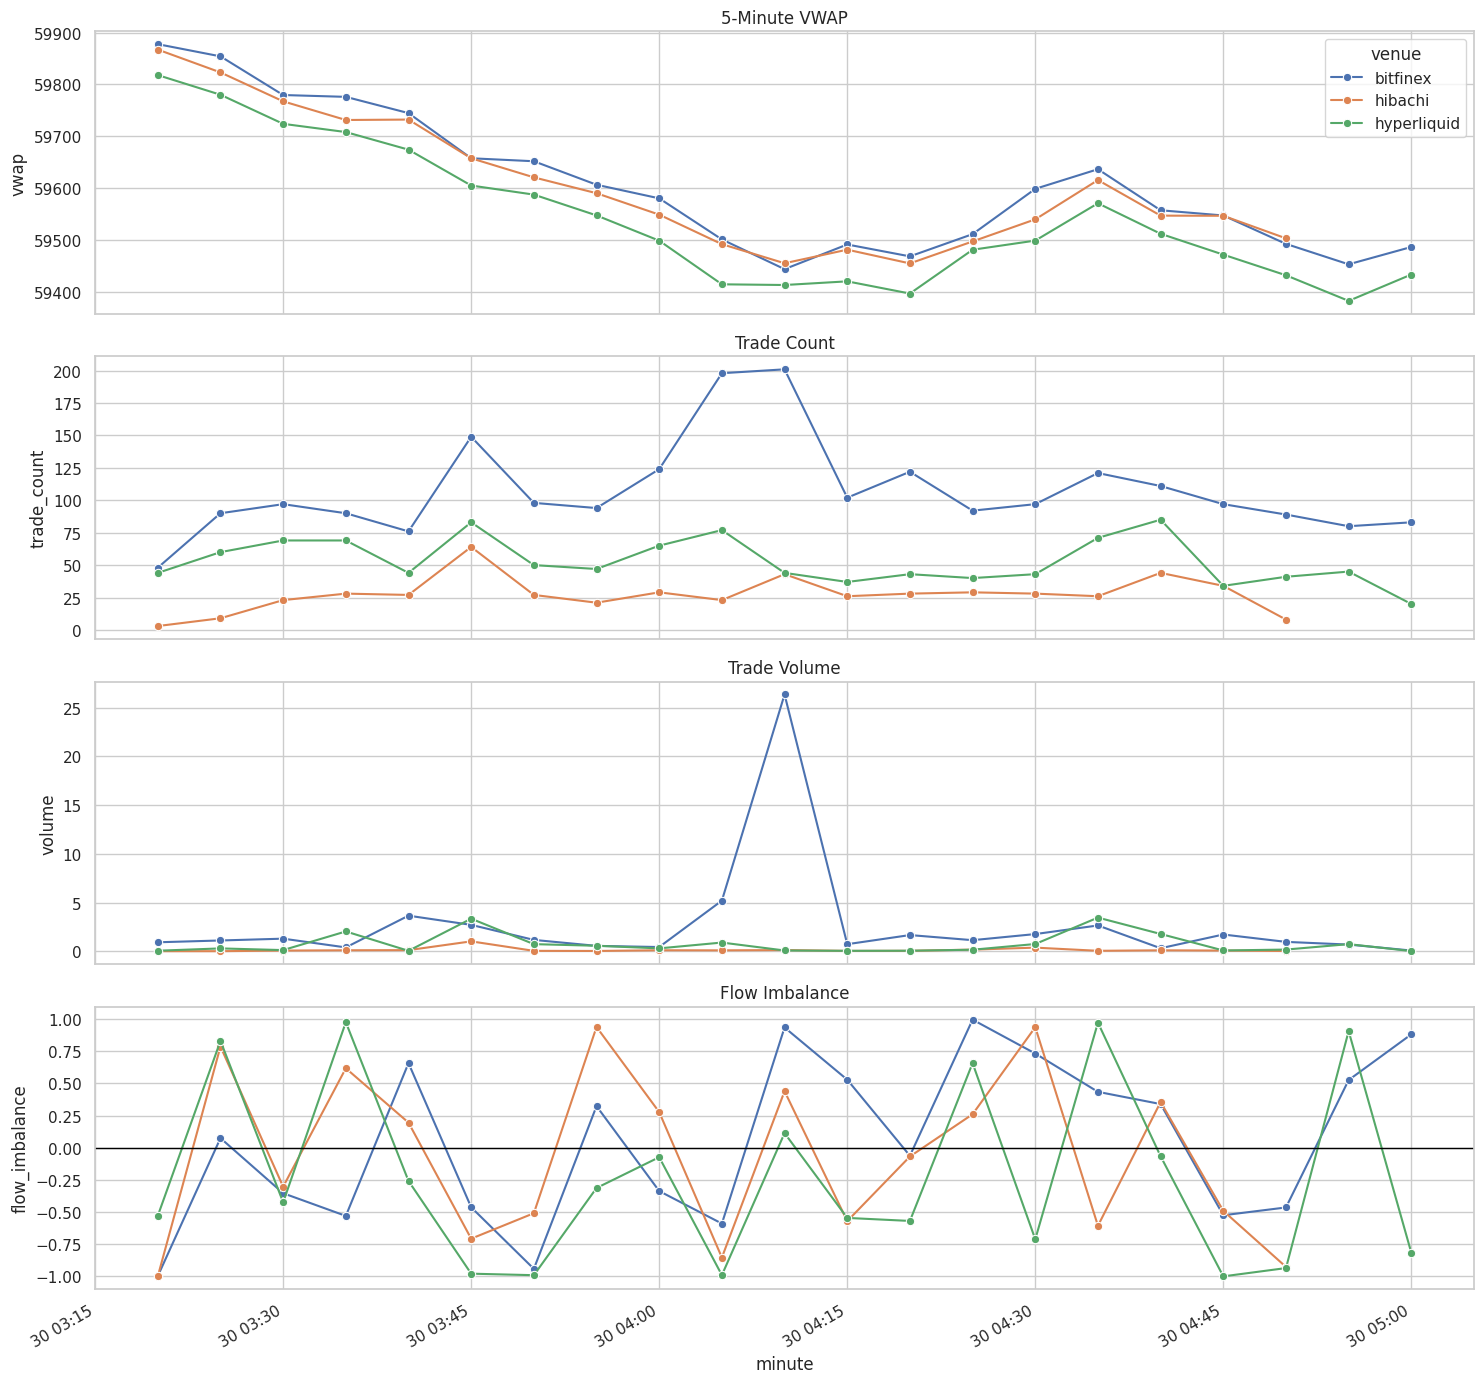

In [5]:
trade_pdf = trade_features.to_pandas()
fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)
sns.lineplot(data=trade_pdf, x="minute", y="vwap", hue="venue", marker="o", ax=axes[0])
axes[0].set_title(f"{BAR_MINUTES}-Minute VWAP")
sns.lineplot(data=trade_pdf, x="minute", y="trade_count", hue="venue", marker="o", ax=axes[1], legend=False)
axes[1].set_title("Trade Count")
sns.lineplot(data=trade_pdf, x="minute", y="volume", hue="venue", marker="o", ax=axes[2], legend=False)
axes[2].set_title("Trade Volume")
sns.lineplot(data=trade_pdf, x="minute", y="flow_imbalance", hue="venue", marker="o", ax=axes[3], legend=False)
axes[3].axhline(0, color="black", linewidth=1)
axes[3].set_title("Flow Imbalance")
fig.autofmt_xdate(); plt.tight_layout()

## Book And Quote Features

In [6]:
book_features.head(30)

minute,mid,spread,top_imbalance,quote_count,venue,spread_bps,depth_imbalance,level_rows
datetime[μs],f64,f64,f64,u32,str,f64,f64,u32
2026-06-30 03:20:00,59890.633333,39.4,null,null,"""bitfinex_updates""",6.578658,0.174406,242
2026-06-30 03:25:00,59854.322917,26.326389,null,null,"""bitfinex_updates""",4.398411,-0.059885,5395
2026-06-30 03:30:00,59788.116595,29.652361,null,null,"""bitfinex_updates""",4.959574,0.017649,9411
2026-06-30 03:35:00,59765.383309,31.487445,null,null,"""bitfinex_updates""",5.268509,-0.036924,8521
2026-06-30 03:40:00,59743.570842,27.486653,null,null,"""bitfinex_updates""",4.600772,-0.063907,5508
2026-06-30 03:45:00,59661.200387,31.070876,null,null,"""bitfinex_updates""",5.207887,-0.057577,10469
2026-06-30 03:50:00,59648.366613,28.292332,null,null,"""bitfinex_updates""",4.743186,-0.005916,7526
2026-06-30 03:55:00,59610.750784,28.451411,null,null,"""bitfinex_updates""",4.772866,-0.083965,7516
2026-06-30 04:00:00,59576.976882,27.927345,null,null,"""bitfinex_updates""",4.687607,-0.032168,9597


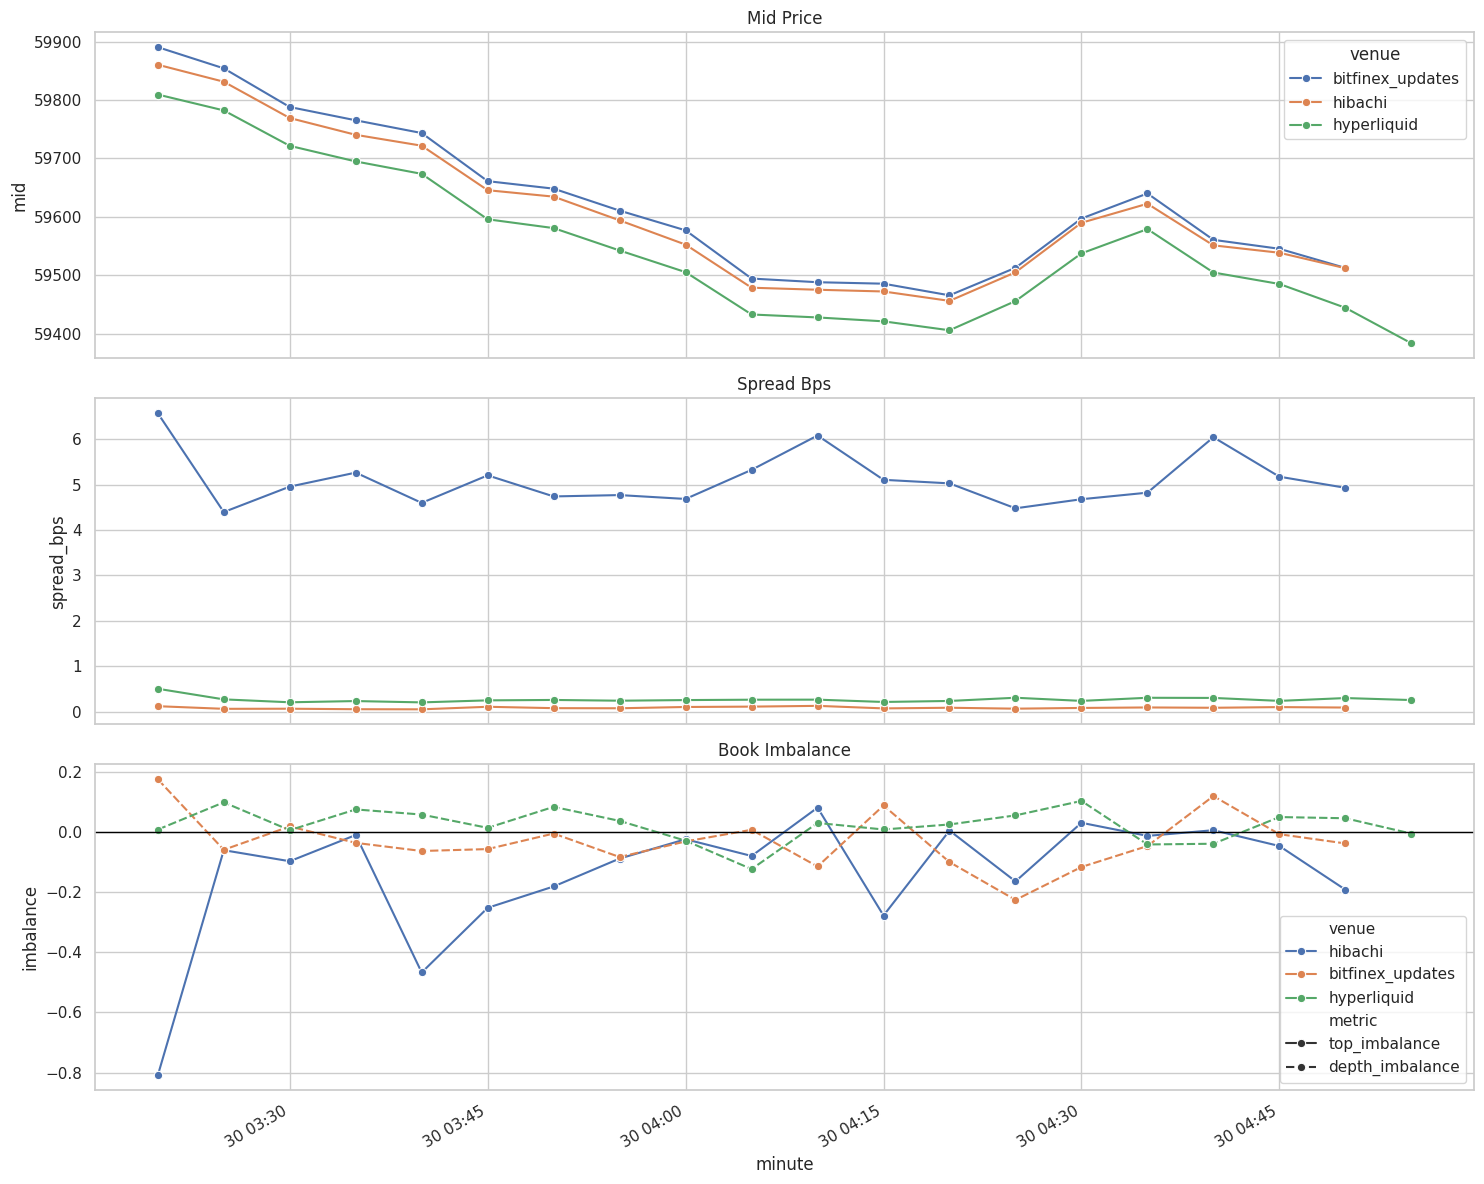

In [7]:
book_pdf = book_features.to_pandas()
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
sns.lineplot(data=book_pdf, x="minute", y="mid", hue="venue", marker="o", ax=axes[0])
axes[0].set_title("Mid Price")
sns.lineplot(data=book_pdf, x="minute", y="spread_bps", hue="venue", marker="o", ax=axes[1], legend=False)
axes[1].set_title("Spread Bps")
imbalance_pdf = book_pdf.melt(
    id_vars=["minute", "venue"],
    value_vars=[column for column in ["top_imbalance", "depth_imbalance"] if column in book_pdf.columns],
    var_name="metric",
    value_name="imbalance",
).dropna()
sns.lineplot(data=imbalance_pdf, x="minute", y="imbalance", hue="venue", style="metric", marker="o", ax=axes[2])
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Book Imbalance")
fig.autofmt_xdate(); plt.tight_layout()

## Realized Volatility And Bipower Variation Features

In [8]:
rv_features.tail(30)

,reference_price,log_price,ret_5m,ret_15m,ret_30m,ret_60m,rv_5m,bpv_5m,jump_var_5m,jump_share_5m,rv_15m,bpv_15m,jump_var_15m,jump_share_15m,rv_30m,bpv_30m,jump_var_30m,jump_share_30m,rv_5m_over_30m,bpv_5m_over_rv_5m
minute,,,,,,,,,,,,,,,,,,,,
2026-06-30 03:20:00,59860.531250,10.999773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-30 03:25:00,59831.423963,10.999286,-0.000486,NaN,NaN,NaN,0.157692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-30 03:30:00,59769.251564,10.998247,-0.001040,NaN,NaN,NaN,0.337083,0.288957,0.030129,0.265160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.857228
2026-06-30 03:35:00,59740.519747,10.997766,-0.000481,-0.002007,NaN,NaN,0.155895,0.287306,0.000000,0.000000,0.232948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.842944
2026-06-30 03:40:00,59721.902273,10.997454,-0.000312,-0.001832,NaN,NaN,0.101056,0.157310,0.000000,0.000000,0.222216,0.308859,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.556665
2026-06-30 03:45:00,59645.717255,10.996178,-0.001276,-0.002069,NaN,NaN,0.413862,0.256312,0.105586,0.616446,0.261914,0.294098,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.619317
2026-06-30 03:50:00,59634.699798,10.995993,-0.000185,-0.001773,-0.003780,NaN,0.059894,0.197324,0.000000,0.000000,0.248382,0.254341,0.000000,0.000000,0.240789,NaN,NaN,NaN,0.248741,3.294544
2026-06-30 03:55:00,59594.077475,10.995311,-0.000681,-0.002143,-0.003975,NaN,0.220931,0.144172,0.028025,0.574158,0.273057,0.250418,0.011851,0.158943,0.248938,0.251478,0.000000,0.000000,0.887494,0.652566
2026-06-30 04:00:00,59552.554798,10.994614,-0.000697,-0.001563,-0.003632,NaN,0.225983,0.280044,0.000000,0.000000,0.185711,0.262818,0.000000,0.000000,0.227033,0.249453,0.000000,0.000000,0.995377,1.239224


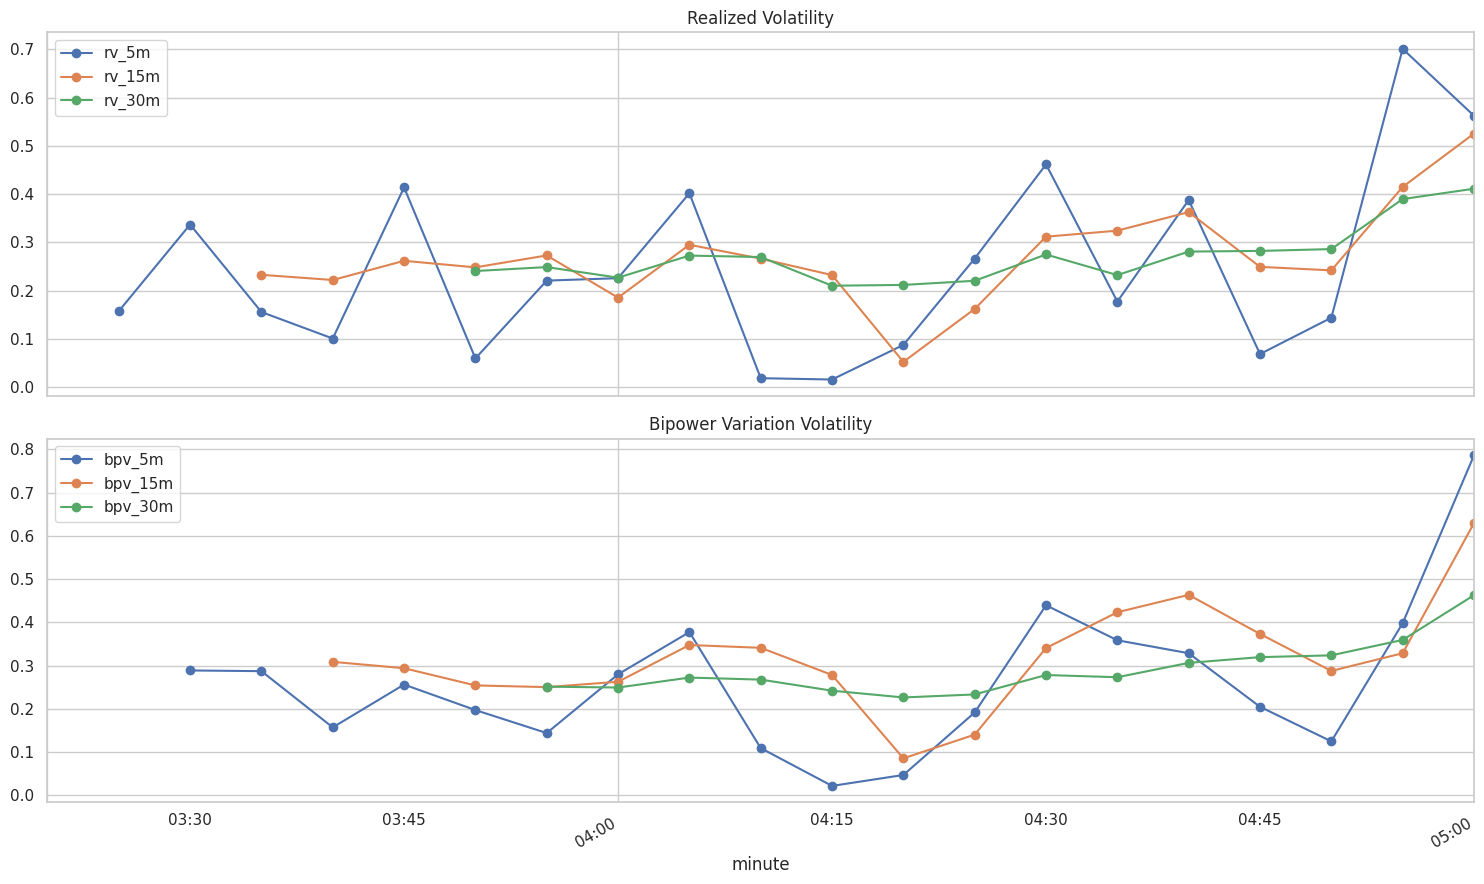

In [9]:
plot_realized_vol(rv_features)

## Deribit IV Term Structure Features

In [10]:
term_structure_features.tail(30)

,iv_0_7d,iv_30_90d,iv_7_30d,iv_90d_plus,iv_0_7d_count,iv_30_90d_count,iv_7_30d_count,iv_90d_plus_count,atm_call,atm_put,atm_put_call_iv_spread,term_slope_30_90_minus_0_7,term_slope_90_plus_minus_7_30,term_curvature,short_iv_decimal
minute,,,,,,,,,,,,,,,
2026-06-30 03:20:00,46.150,40.325,42.000,44.360,170,112,74,72,43.280,43.410,0.130,-5.825,2.360,-4.9300,0.42000
2026-06-30 03:25:00,42.620,40.010,43.210,44.500,170,112,74,72,42.700,42.490,-0.210,-2.610,1.290,-3.5500,0.43210
2026-06-30 03:30:00,42.765,40.490,40.930,44.395,124,111,74,71,42.970,42.575,-0.395,-2.275,3.465,-3.0900,0.40930
2026-06-30 03:35:00,43.140,41.250,42.050,44.525,122,109,74,67,43.300,43.000,-0.300,-1.890,2.475,-2.5825,0.42050
2026-06-30 03:40:00,43.245,39.965,40.545,44.490,129,108,74,71,43.120,42.460,-0.660,-3.280,3.945,-3.9025,0.40545
2026-06-30 03:45:00,43.145,40.225,40.990,44.080,130,108,74,66,42.970,43.000,0.030,-2.920,3.090,-3.3875,0.40990
2026-06-30 03:50:00,43.750,39.815,43.150,44.510,128,111,74,61,43.400,43.280,-0.120,-3.935,1.360,-4.3150,0.43150
2026-06-30 03:55:00,42.470,40.540,44.110,44.100,127,112,74,66,42.690,42.700,0.010,-1.930,-0.010,-2.7450,0.44110
2026-06-30 04:00:00,42.555,40.490,41.150,44.480,124,112,74,69,42.490,42.345,-0.145,-2.065,3.330,-3.0275,0.41150


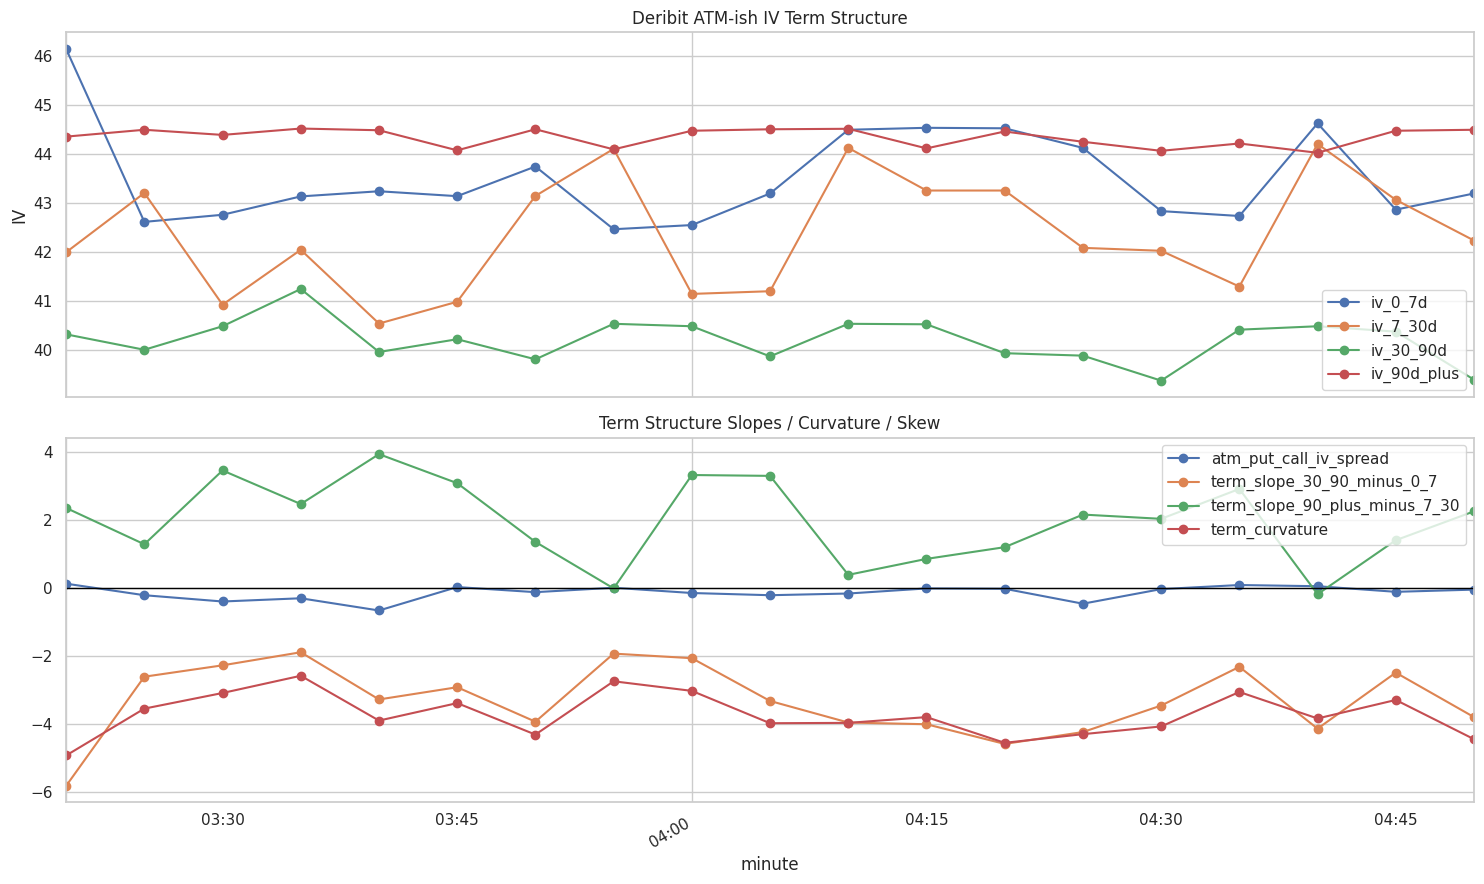

In [11]:
plot_term_structure(term_structure_features)

## Deribit Option Smile Features

In [12]:
option_smile_features.tail(30)

,smile_atm_call_iv,smile_atm_put_iv,smile_otm_call_iv,smile_otm_put_iv,smile_atm_call_iv_count,smile_atm_put_iv_count,smile_otm_call_iv_count,smile_otm_put_iv_count,smile_put_wing_minus_atm,smile_call_wing_minus_atm,smile_risk_reversal_proxy,smile_butterfly_proxy
minute,,,,,,,,,,,,
2026-06-30 03:20:00,42.000,42.195,40.710,49.920,97,92,97,69,7.8225,-1.3875,-9.210,3.2175
2026-06-30 03:25:00,41.040,40.900,39.060,49.910,634,665,383,293,8.9400,-1.9100,-10.850,3.5150
2026-06-30 03:30:00,41.330,41.150,39.130,52.350,977,1024,463,385,11.1100,-2.1100,-13.220,4.5000
2026-06-30 03:35:00,41.630,41.500,39.590,52.420,786,811,417,329,10.8550,-1.9750,-12.830,4.4400
2026-06-30 03:40:00,41.735,41.310,39.385,51.980,676,729,414,269,10.4575,-2.1375,-12.595,4.1600
2026-06-30 03:45:00,41.930,40.985,40.630,52.460,1114,1174,543,341,11.0025,-0.8275,-11.830,5.0875
2026-06-30 03:50:00,42.085,41.500,39.770,52.735,702,758,413,300,10.9425,-2.0225,-12.965,4.4600
2026-06-30 03:55:00,41.090,40.520,40.285,51.885,742,822,414,316,11.0800,-0.5200,-11.600,5.2800
2026-06-30 04:00:00,41.100,40.710,40.115,51.180,894,947,520,336,10.2750,-0.7900,-11.065,4.7425


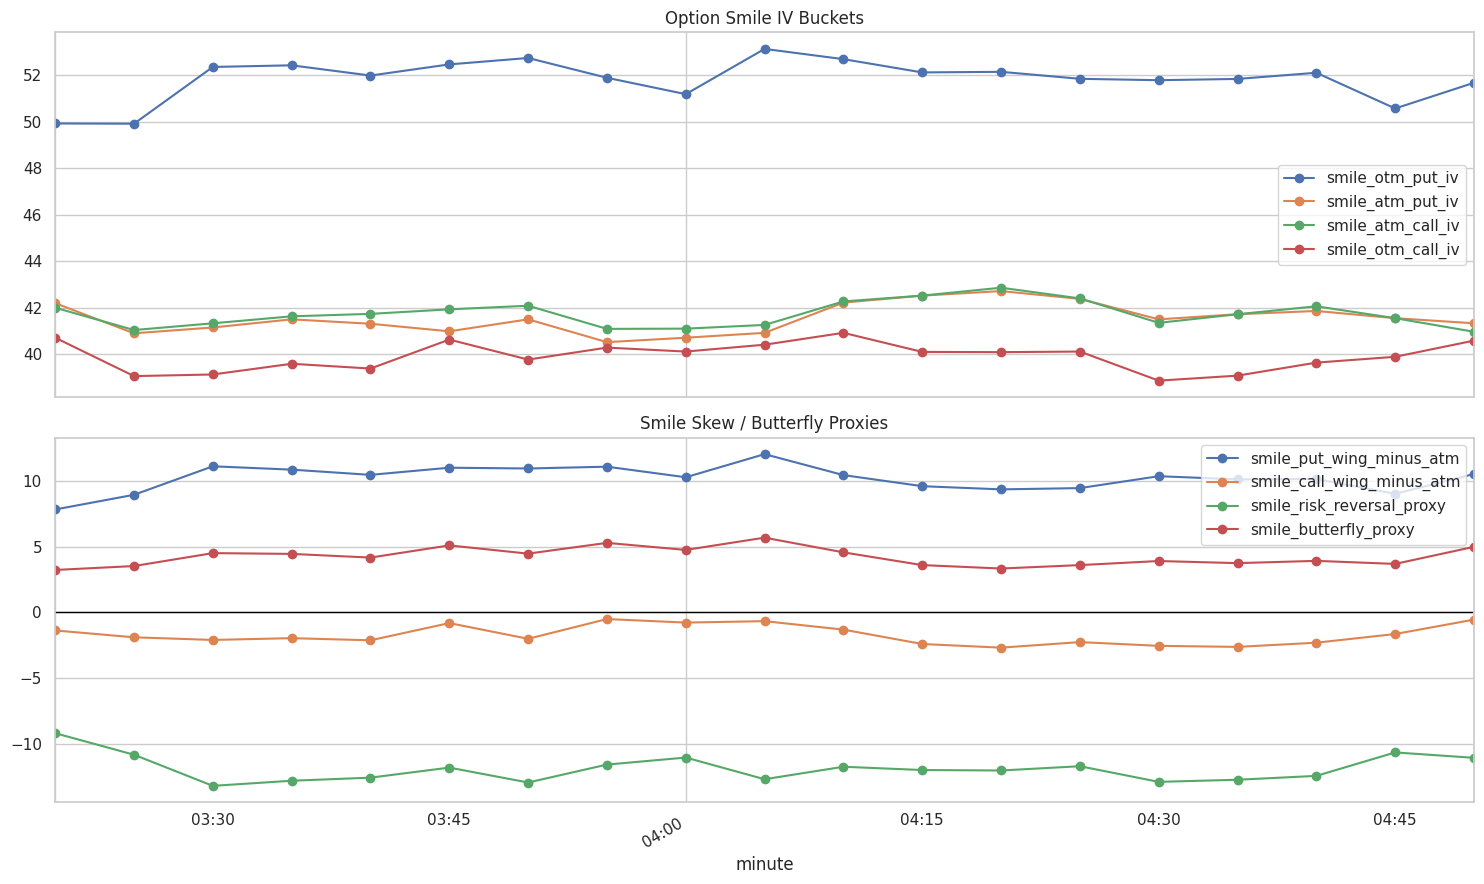

In [13]:
smile_cols = [column for column in ["smile_otm_put_iv", "smile_atm_put_iv", "smile_atm_call_iv", "smile_otm_call_iv"] if column in option_smile_features]
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
option_smile_features[smile_cols].plot(ax=axes[0], marker="o")
axes[0].set_title("Option Smile IV Buckets")
smile_spread_cols = [column for column in option_smile_features.columns if column.endswith("proxy") or column.endswith("minus_atm")]
option_smile_features[smile_spread_cols].plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Smile Skew / Butterfly Proxies")
fig.autofmt_xdate(); plt.tight_layout()

## Deribit Futures Basis Features

In [14]:
futures_basis_features.tail(30)

,basis_fut_0_7d,basis_fut_30_90d,basis_fut_7_30d,basis_fut_90d_plus,basis_fut_perp,basis_fut_0_7d_annualized,basis_fut_30_90d_annualized,basis_fut_7_30d_annualized,basis_fut_90d_plus_annualized,basis_fut_perp_annualized,basis_fut_0_7d_count,basis_fut_30_90d_count,basis_fut_7_30d_count,basis_fut_90d_plus_count,basis_fut_perp_count,basis_future_basis_slope_30_90_minus_0_7,basis_future_basis_slope_90_plus_minus_7_30
minute,,,,,,,,,,,,,,,,,
2026-06-30 03:20:00,-0.083621,45.594090,9.215649,280.059421,0.408061,-37.534918,281.152281,248.138361,379.735823,NaN,4,3,2,3,1,45.677711,270.843772
2026-06-30 03:25:00,0.854762,47.196877,8.294066,280.965621,0.202413,196.811211,291.049110,279.367548,380.968435,NaN,4,3,2,3,1,46.342115,272.671555
2026-06-30 03:30:00,-0.102153,46.525540,10.810960,279.346729,0.278816,-29.661924,286.922569,246.259764,378.778723,NaN,4,3,2,3,1,46.627693,268.535769
2026-06-30 03:35:00,0.705480,46.900924,11.199330,279.969630,0.709400,212.151299,289.255198,261.604699,379.626450,NaN,4,3,2,3,1,46.195443,268.770299
2026-06-30 03:40:00,0.815523,47.005572,11.704386,279.908001,0.763416,277.817267,289.916618,266.404561,379.550714,NaN,4,3,2,3,1,46.190049,268.203616
2026-06-30 03:45:00,1.518386,46.948168,11.820164,280.025919,1.334946,302.593231,289.584661,283.241307,379.712198,NaN,4,3,2,3,1,45.429782,268.205755
2026-06-30 03:50:00,1.303745,48.079965,12.502917,280.342130,1.342413,308.977915,296.574885,284.068310,380.145984,NaN,4,3,2,3,1,46.776219,267.839213
2026-06-30 03:55:00,0.519790,47.937085,12.543898,280.243776,1.210886,210.038085,295.710393,277.916872,380.018408,NaN,4,3,2,3,1,47.417295,267.699878
2026-06-30 04:00:00,0.765201,48.159093,12.769126,280.385578,1.635991,241.659051,297.102019,289.050450,380.214024,NaN,4,3,2,3,1,47.393892,267.616452


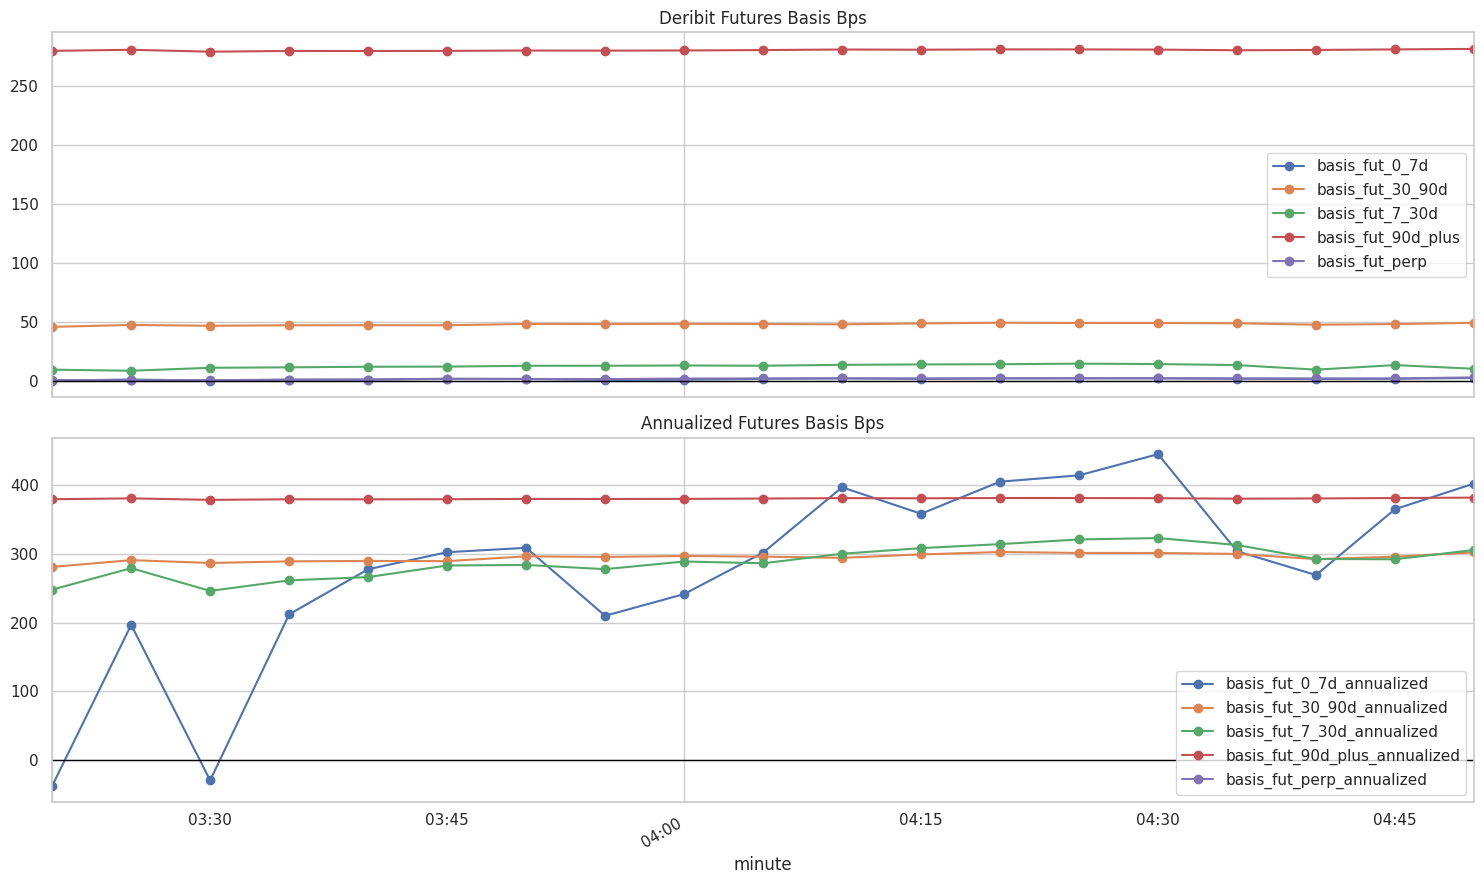

In [15]:
basis_cols = [column for column in futures_basis_features.columns if column.startswith("basis_fut_") and not column.endswith("count") and not column.endswith("annualized")]
ann_cols = [column for column in futures_basis_features.columns if column.endswith("annualized")]
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
futures_basis_features[basis_cols].plot(ax=axes[0], marker="o")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Deribit Futures Basis Bps")
futures_basis_features[ann_cols].plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Annualized Futures Basis Bps")
fig.autofmt_xdate(); plt.tight_layout()

## Funding Features

In [16]:
funding_features.tail(30)

,estimated_funding_rate,funding_updates
minute,,
2026-06-30 03:20:00,0.000037,16
2026-06-30 03:25:00,0.000036,699
2026-06-30 03:30:00,0.000036,991
2026-06-30 03:35:00,0.000035,990
2026-06-30 03:40:00,0.000035,990
2026-06-30 03:45:00,0.000036,991
2026-06-30 03:50:00,0.000037,991
2026-06-30 03:55:00,0.000037,990
2026-06-30 04:00:00,0.000037,990


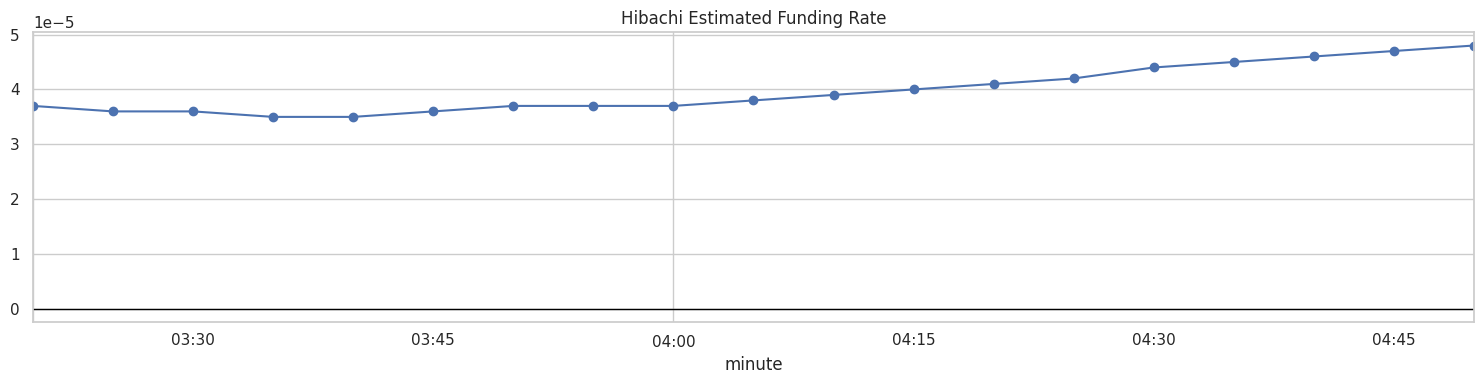

In [17]:
fig, ax = plt.subplots(figsize=(15, 4))
funding_features["estimated_funding_rate"].plot(ax=ax, marker="o")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Hibachi Estimated Funding Rate")
plt.tight_layout()

## Feature Matrix

In [18]:
feature_matrix.tail(20)

,trade_flow_imbalance_bitfinex,trade_flow_imbalance_hibachi,trade_flow_imbalance_hyperliquid,trade_trade_count_bitfinex,trade_trade_count_hibachi,trade_trade_count_hyperliquid,trade_volume_bitfinex,trade_volume_hibachi,trade_volume_hyperliquid,trade_vwap_bitfinex,trade_vwap_hibachi,trade_vwap_hyperliquid,book_depth_imbalance_bitfinex_updates,book_depth_imbalance_hyperliquid,book_mid_bitfinex_updates,book_mid_hibachi,book_mid_hyperliquid,book_spread_bps_bitfinex_updates,book_spread_bps_hibachi,book_spread_bps_hyperliquid,book_top_imbalance_hibachi,option_tick_count,active_options,median_mark_iv,median_index_price,open_interest_sum,estimated_funding_rate,funding_updates,mid_hibachi_minus_hyperliquid,mid_hibachi_minus_hyperliquid_bps,spread_bps_hibachi_minus_hyperliquid,cross_venue_flow_imbalance_mean,cross_venue_flow_imbalance_std,cross_venue_volume_sum,cross_venue_spread_bps_mean,cross_venue_spread_bps_std,reference_price,log_price,ret_5m,ret_15m,ret_30m,ret_60m,rv_5m,bpv_5m,jump_var_5m,jump_share_5m,rv_15m,bpv_15m,jump_var_15m,jump_share_15m,rv_30m,bpv_30m,jump_var_30m,jump_share_30m,rv_5m_over_30m,bpv_5m_over_rv_5m,iv_0_7d,iv_30_90d,iv_7_30d,iv_90d_plus,iv_0_7d_count,iv_30_90d_count,iv_7_30d_count,iv_90d_plus_count,atm_call,atm_put,atm_put_call_iv_spread,term_slope_30_90_minus_0_7,term_slope_90_plus_minus_7_30,term_curvature,short_iv_decimal,smile_atm_call_iv,smile_atm_put_iv,smile_otm_call_iv,smile_otm_put_iv,smile_atm_call_iv_count,smile_atm_put_iv_count,smile_otm_call_iv_count,smile_otm_put_iv_count,smile_put_wing_minus_atm,smile_call_wing_minus_atm,smile_risk_reversal_proxy,smile_butterfly_proxy,basis_fut_0_7d,basis_fut_30_90d,basis_fut_7_30d,basis_fut_90d_plus,basis_fut_perp,basis_fut_0_7d_annualized,basis_fut_30_90d_annualized,basis_fut_7_30d_annualized,basis_fut_90d_plus_annualized,basis_fut_perp_annualized,basis_fut_0_7d_count,basis_fut_30_90d_count,basis_fut_7_30d_count,basis_fut_90d_plus_count,basis_fut_perp_count,basis_future_basis_slope_30_90_minus_0_7,basis_future_basis_slope_90_plus_minus_7_30,trade_flow_imbalance_bitfinex_diff_5m,trade_flow_imbalance_bitfinex_mean_5m,trade_flow_imbalance_bitfinex_z_5m,trade_flow_imbalance_bitfinex_mean_15m,trade_flow_imbalance_bitfinex_z_15m,trade_flow_imbalance_bitfinex_mean_30m,trade_flow_imbalance_bitfinex_z_30m,trade_flow_imbalance_hibachi_diff_5m,trade_flow_imbalance_hibachi_mean_5m,trade_flow_imbalance_hibachi_z_5m,trade_flow_imbalance_hibachi_mean_15m,trade_flow_imbalance_hibachi_z_15m,trade_flow_imbalance_hibachi_mean_30m,trade_flow_imbalance_hibachi_z_30m,trade_flow_imbalance_hyperliquid_diff_5m,trade_flow_imbalance_hyperliquid_mean_5m,trade_flow_imbalance_hyperliquid_z_5m,trade_flow_imbalance_hyperliquid_mean_15m,trade_flow_imbalance_hyperliquid_z_15m,trade_flow_imbalance_hyperliquid_mean_30m,...,jump_share_5m_z_30m,rv_15m_diff_5m,rv_15m_mean_5m,rv_15m_z_5m,rv_15m_mean_15m,rv_15m_z_15m,rv_15m_mean_30m,rv_15m_z_30m,bpv_15m_diff_5m,bpv_15m_mean_5m,bpv_15m_z_5m,bpv_15m_mean_15m,bpv_15m_z_15m,bpv_15m_mean_30m,bpv_15m_z_30m,jump_var_15m_diff_5m,jump_var_15m_mean_5m,jump_var_15m_z_5m,jump_var_15m_mean_15m,jump_var_15m_z_15m,jump_var_15m_mean_30m,jump_var_15m_z_30m,jump_share_15m_diff_5m,jump_share_15m_mean_5m,jump_share_15m_z_5m,jump_share_15m_mean_15m,jump_share_15m_z_15m,jump_share_15m_mean_30m,jump_share_15m_z_30m,rv_30m_diff_5m,rv_30m_mean_5m,rv_30m_z_5m,rv_30m_mean_15m,rv_30m_z_15m,rv_30m_mean_30m,rv_30m_z_30m,bpv_30m_diff_5m,bpv_30m_mean_5m,bpv_30m_z_5m,bpv_30m_mean_15m,bpv_30m_z_15m,bpv_30m_mean_30m,bpv_30m_z_30m,jump_var_30m_diff_5m,jump_var_30m_mean_5m,jump_var_30m_z_5m,jump_var_30m_mean_15m,jump_var_30m_z_15m,jump_var_30m_mean_30m,jump_var_30m_z_30m,jump_share_30m_diff_5m,jump_share_30m_mean_5m,jump_share_30m_z_5m,jump_share_30m_mean_15m,jump_share_30m_z_15m,jump_share_30m_mean_30m,jump_share_30m_z_30m,rv_5m_over_30m_diff_5m,rv_5m_over_30m_mean_5m,rv_5m_over_30m_z_5m,rv_5m_over_30m_mean_15m,rv_5m_over_30m_z_15m,rv_5m_over_30m_mean_30m,rv_5m_over_30m_z_30m,bpv_5m_o

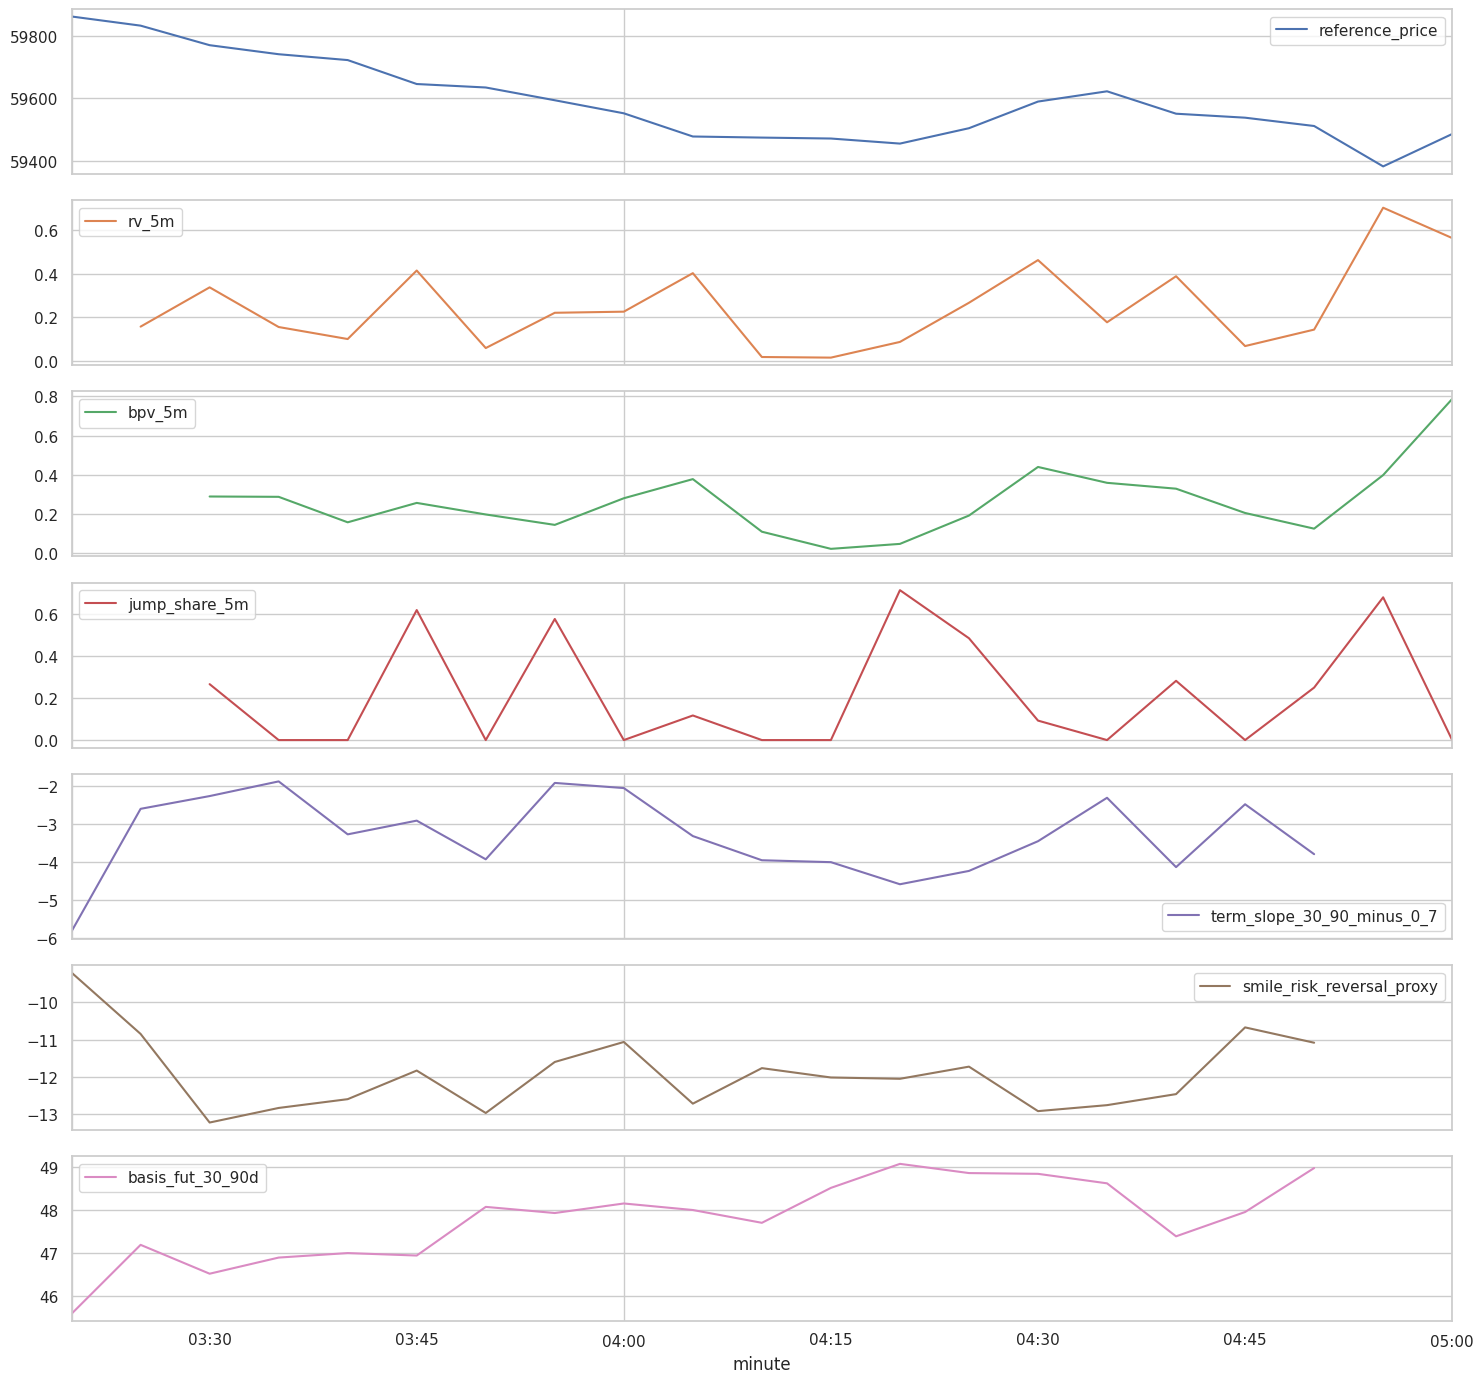

In [19]:
selected = [
    column for column in feature_matrix.columns
    if column in ["reference_price", "rv_5m", "bpv_5m", "jump_share_5m", "term_slope_30_90_minus_0_7", "smile_risk_reversal_proxy", "basis_fut_30_90d"]
]
feature_matrix[selected].plot(figsize=(15, max(4, 2 * len(selected))), subplots=True, layout=(len(selected), 1), sharex=True, legend=True)
plt.tight_layout()

## Optional Save

In [20]:
if SAVE_OUTPUTS:
    out_dir = FEATURE_ROOT / DATE / f"bar_{BAR_MINUTES}m"
    out_dir.mkdir(parents=True, exist_ok=True)
    feature_matrix.to_parquet(out_dir / "feature_matrix.parquet")
    base_feature_matrix.to_parquet(out_dir / "base_feature_matrix.parquet")
    print(f"wrote features to {out_dir}")
else:
    print("SAVE_OUTPUTS is false; nothing written")

SAVE_OUTPUTS is false; nothing written
